In [2]:
import isofit
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.utils.apply_oe import apply_oe 

from collections import OrderedDict

import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt

from isoplots import plots

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [5]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'test_flightlines/')
raw = os.path.join(data, 'raw/rmbl/')

flights = ['NIS01_20180612_155442', 'NIS01_20180619_162542', 'NIS01_20180620_162340'] 

fp_rcc = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250807.txt')
fp_rcc_v1 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v1.txt')
fp_rcc_v2 = os.path.join(data, 'test_roi/rcc_white_tarp_mean_20250814_v2.txt')

fp = glob(os.path.join(home, '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

In [6]:
# learning about isofit rt formulation, isoplots

flight = flights[0]
working_dir = glob(os.path.join(home+f'{flight}*'))[0]
fp_lut = os.path.join(working_dir, 'lut_full', 'lut.nc')

config = configs.create_new_config(os.path.join(working_dir, 'config', f'{flight}_isofit.json'))
fm = ForwardModel(config)
io = IO(config, fm)
inv = Inversion(config, fm)

input_data = io.get_components_at_index(10000, 0) # superpixels
meas = input_data.meas; geom=input_data.geom

states=inv.invert(meas, geom)
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

INFO:root:Loading config file: /store/carroll/col/data/2018/test_flightlines/NIS01_20180612_155442_sRTMnet_20250808/config/NIS01_20180612_155442_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_flightlines/NIS01_20180612_155442_sRTMnet_20250808/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 17472 ;

variables:
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	float64 wl(wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;
	float64 observer_zenith(point) ;
	float64 relative_azimuth(point) ;
	float64 surface_elevation_km(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None, 'observer_zenith': None, 'relative_azimuth': None, 'surface_elevation_km': None} ;
}

ERROR:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/data/ini.py:[x] Data path does not exist
ERROR:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/data/ini.py:The following path does not exist, please verify your installation environment: /home/carroll/extra-downloads/data/earth_sun_distance.txt


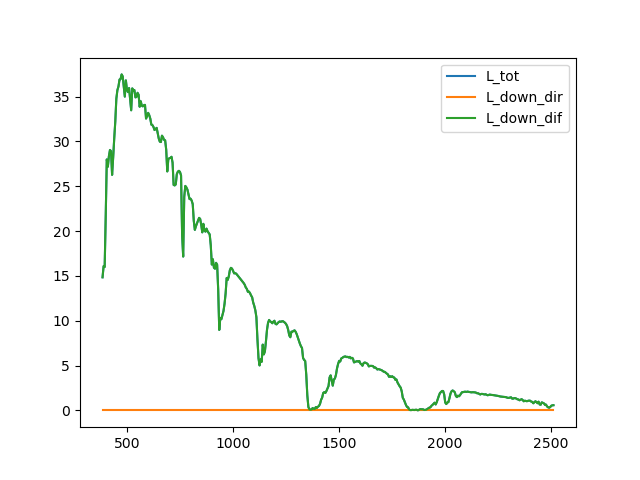

In [43]:
# Get RT quantities including the LUT sample (r) and the radiances (L)
(
    r,
    L_tot,
    L_down_dir,
    L_down_dif,
    L_dir_dir,
    L_dif_dir,
    L_dir_dif,
    L_dif_dif,
) = fm.RT.calc_RT_quantities(x_RT, geom)

L_tot, L_down_dir, L_down_dif, L_dir_dir, L_dif_dir, L_dir_dif, L_dif_dif # only L_down_dif is populated, all else are 0

# everything is zero except L_down_dif (and L_tot==L_down_dif)

fig = plt.figure()
plt.plot(wl, L_tot, label='L_tot')
plt.plot(wl, L_down_dir, label='L_down_dir')
plt.plot(wl, L_down_dif, label='L_down_dif')
# plt.plot(wl, L_dir_dir, label='L_dir_dir')
# plt.plot(wl, L_dif_dir, label='L_dif_dir')
# plt.plot(wl, L_dir_dif, label='L_dir_dif')
# plt.plot(wl, L_dif_dif, label='L_dif_dif')

plt.legend()
plt.show()

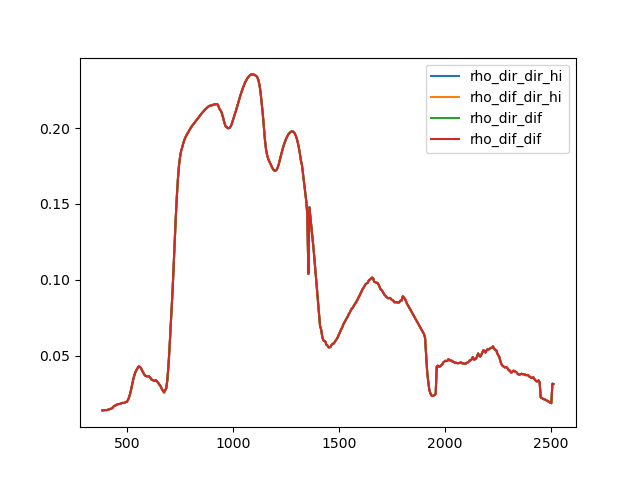

In [47]:
# get the reflectance from the target to the sensor

rho_dir_dir, rho_dif_dir = fm.calc_rfl(x_surface, geom)
rho_dir_dir_hi = fm.upsample(fm.surface.wl, rho_dir_dir)
rho_dif_dir_hi = fm.upsample(fm.surface.wl, rho_dif_dir)

rho_dir_dif = rho_dir_dir
rho_dif_dif = rho_dif_dir

# they're the same because of the lambertian assumption
fig = plt.figure()
plt.plot(wl, rho_dir_dir_hi, label='rho_dir_dir_hi')
plt.plot(wl, rho_dif_dir_hi, label='rho_dif_dir_hi')
plt.plot(wl, rho_dir_dif, label='rho_dir_dif')
plt.plot(wl, rho_dif_dif, label='rho_dif_dif')
plt.legend()
plt.show()

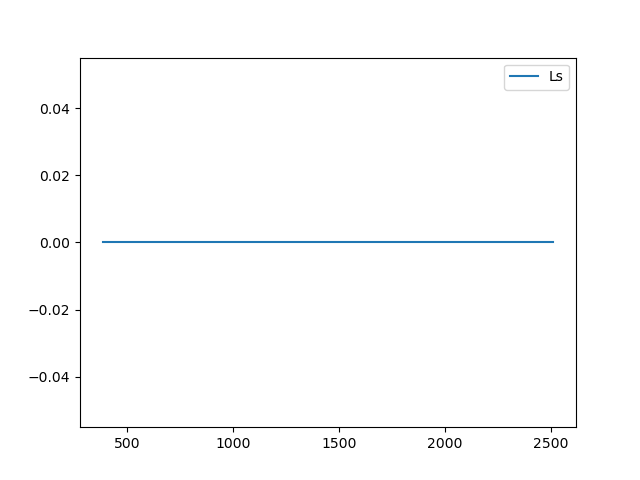

In [55]:
# the surface emission (Ls) is the radiance being emitted by the surface. In the solar-reflective region, Ls is effectively -, but it's more important in the thermal IR

Ls = fm.upsample(fm.surface.wl, fm.calc_Ls(x_surface, geom))
fig = plt.figure()
plt.plot(wl, Ls_hi, label='Ls')
plt.legend()
plt.show()

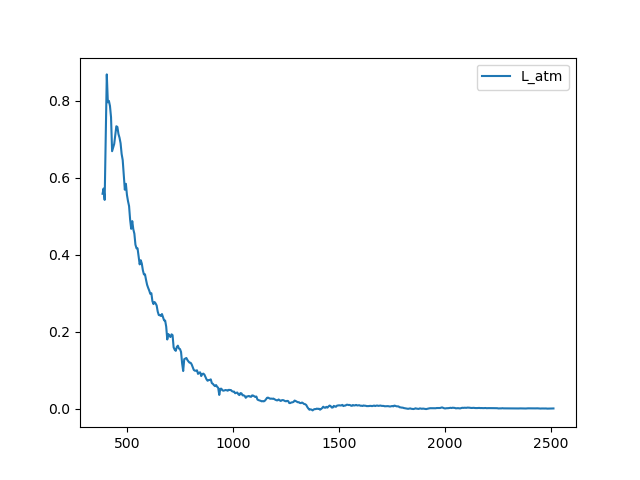

In [46]:
# atmospheric path radiance
L_atm = fm.RT.get_L_atm(x_RT, geom)
fig = plt.figure()
plt.plot(wl, L_atm, label='L_atm')
plt.legend()
plt.show()

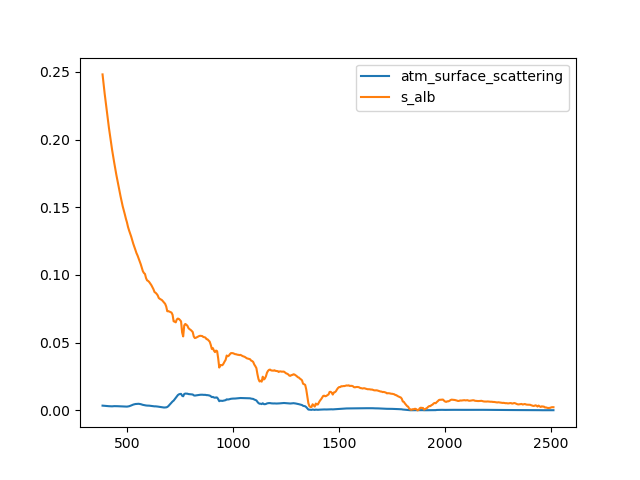

In [67]:
# atmospheric surface albedo
s_alb = r["sphalb"]
atm_surface_scattering = s_alb * rho_dif_dif

fig = plt.figure()
plt.plot(wl, atm_surface_scattering, label='atm_surface_scattering')
plt.plot(wl, s_alb, label='s_alb')
plt.legend()
plt.show()

In [50]:
# Special case: 1-component model
if not isinstance(L_dir_dir, np.ndarray) or len(L_dir_dir) == 1:
    print('1c')
    # we assume rho_dir_dir = rho_dif_dir = rho_dir_dif = rho_dif_dif
    rho_dif_dif = rho_dir_dir
    # eliminate spherical albedo and one reflectance term from numerator if using 1-component model
    atm_surface_scattering = 1

1c


In [57]:
# Thermal transmittance
L_up = Ls * (r["transm_up_dir"] + r["transm_up_dif"])
L_up

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [69]:
# TOA radiance model
ret = (
    L_atm
    # + L_dir_dir * rho_dir_dir # these are all zero
    # + L_dif_dir * rho_dif_dir
    # + L_dir_dif * rho_dir_dif
    # + L_dif_dif * rho_dif_dif
    + (L_tot * atm_surface_scattering * rho_dif_dif) / (1 - s_alb * rho_dif_dif)
            # numerator - what came from sun, and then was reflected away by the atmosphere, and then of that what was reflected back by the object
            # denomenator... accounts for what is lost on teh way from the target back up to the sensor
    + L_up
)

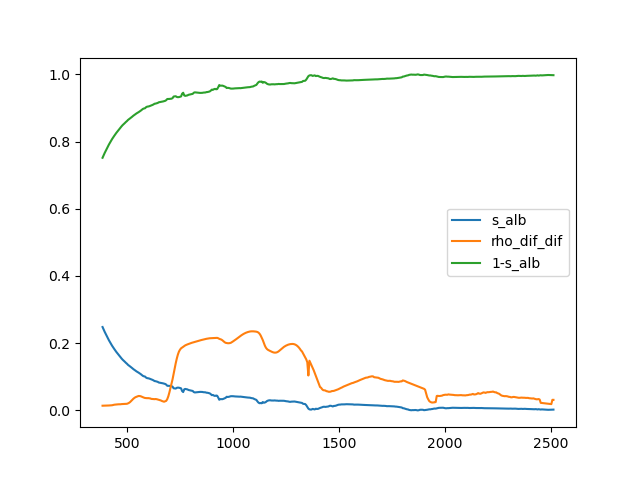

In [72]:
fig = plt.figure()
plt.plot(wl, s_alb, label='s_alb')
plt.plot(wl, rho_dif_dif, label='rho_dif_dif')
plt.plot(wl, 1-s_alb, label='1-s_alb')
plt.legend()
plt.show()

/tmp/ipykernel_92657/3721305974.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


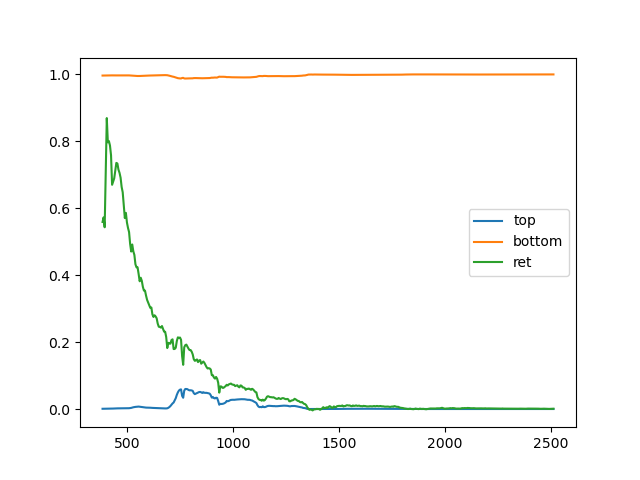

In [70]:
top = L_tot * atm_surface_scattering * rho_dif_dif
bottom = 1 - s_alb * rho_dif_dif

fig = plt.figure()
plt.plot(wl, top, label='top')
plt.plot(wl, bottom, label='bottom')
plt.plot(wl, ret, label='ret')
plt.legend()
plt.show()

Loading /store/carroll/col/data/2018/test_flightlines/NIS01_20180612_155442_sRTMnet_20250808/lut_full/lut.nc


INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory


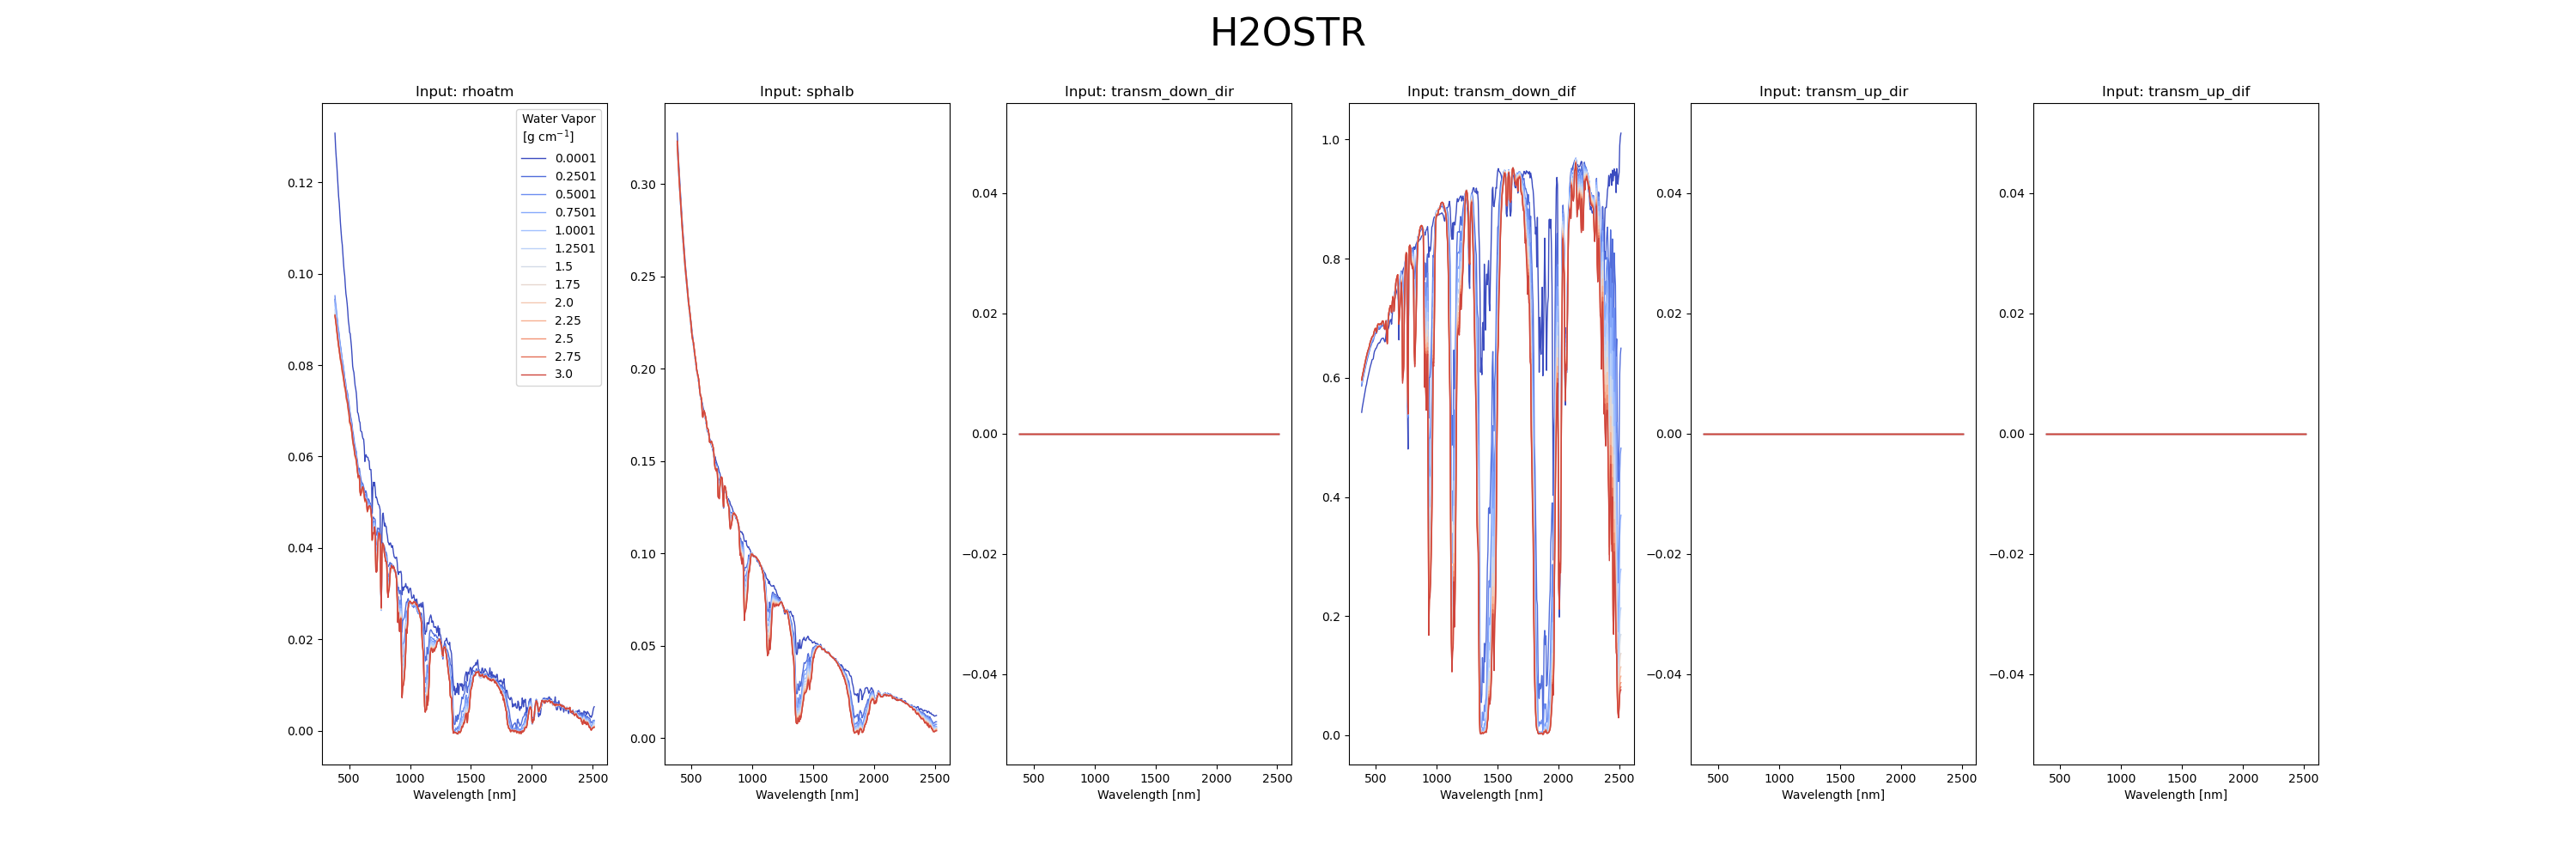

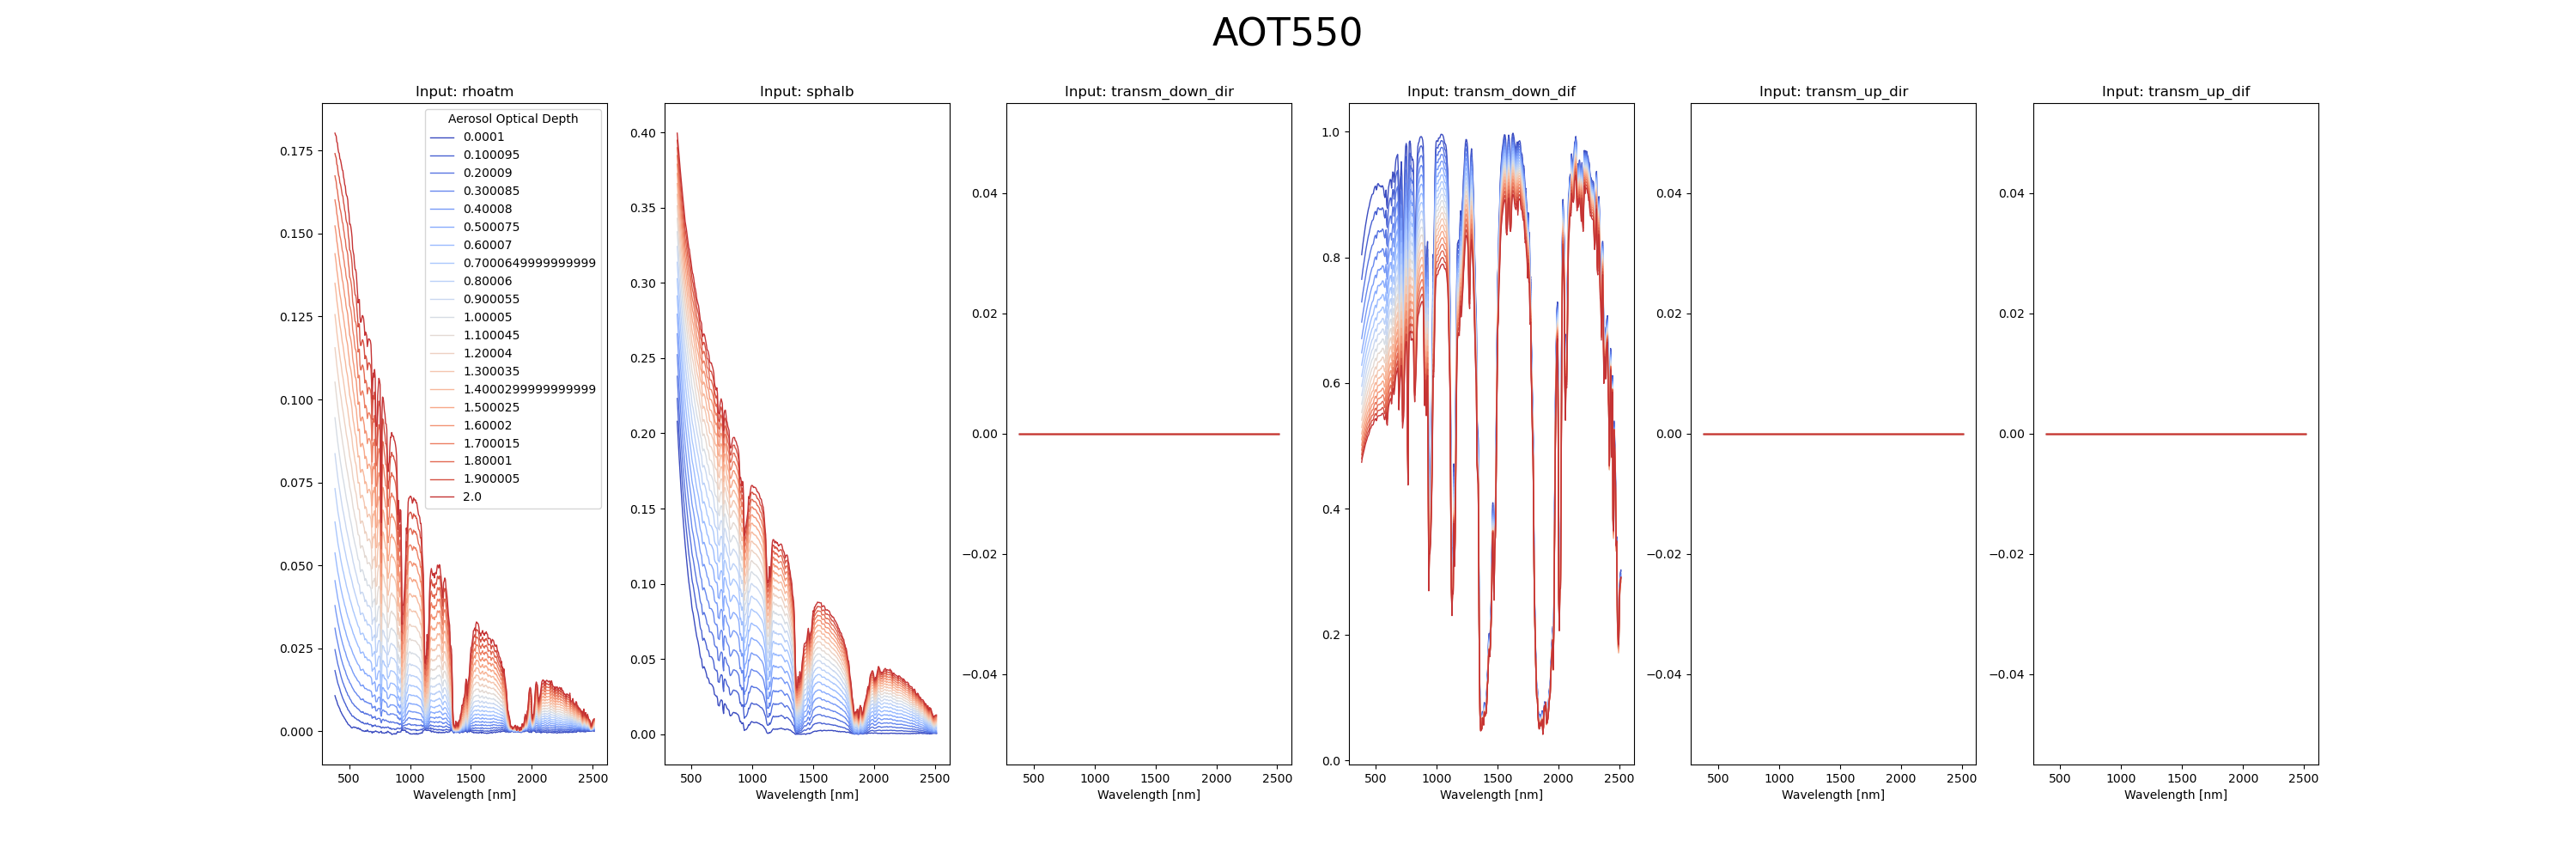

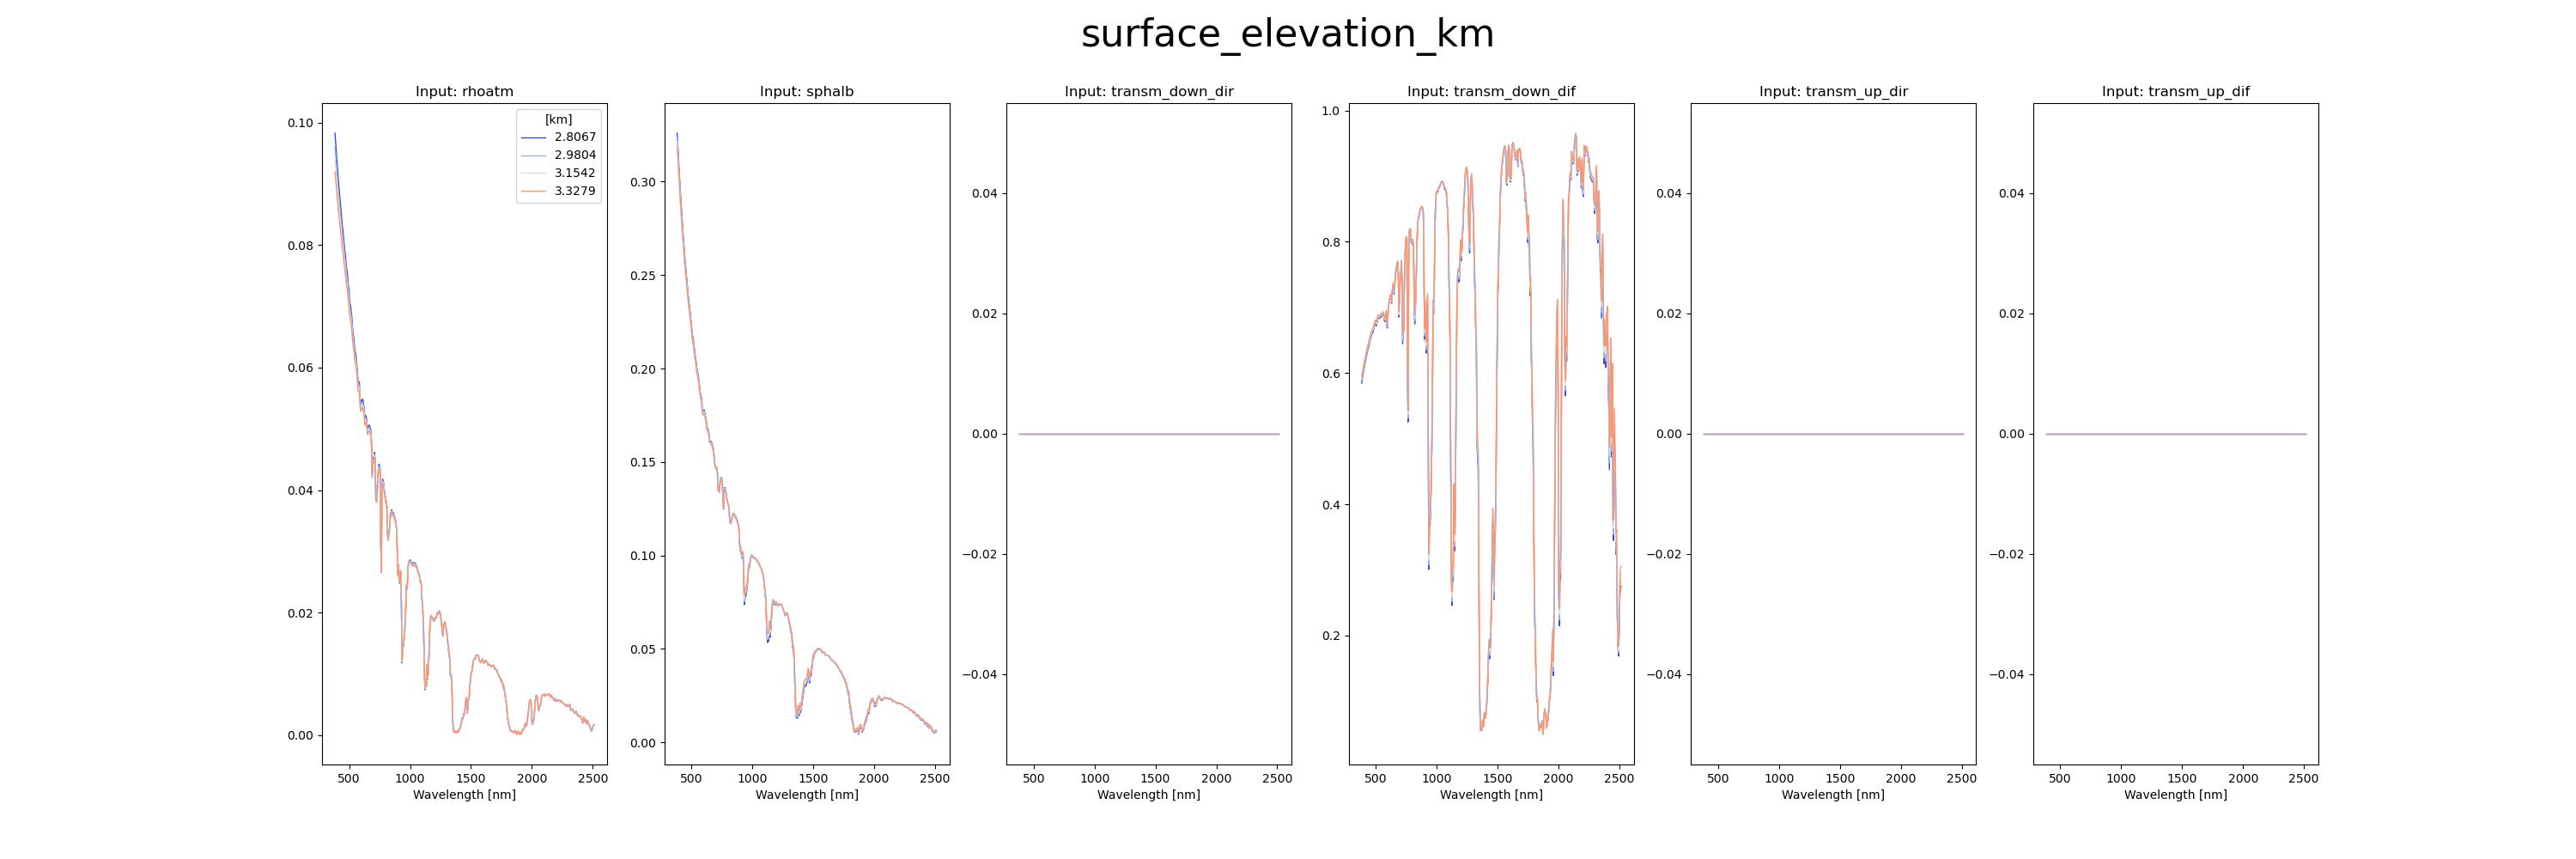

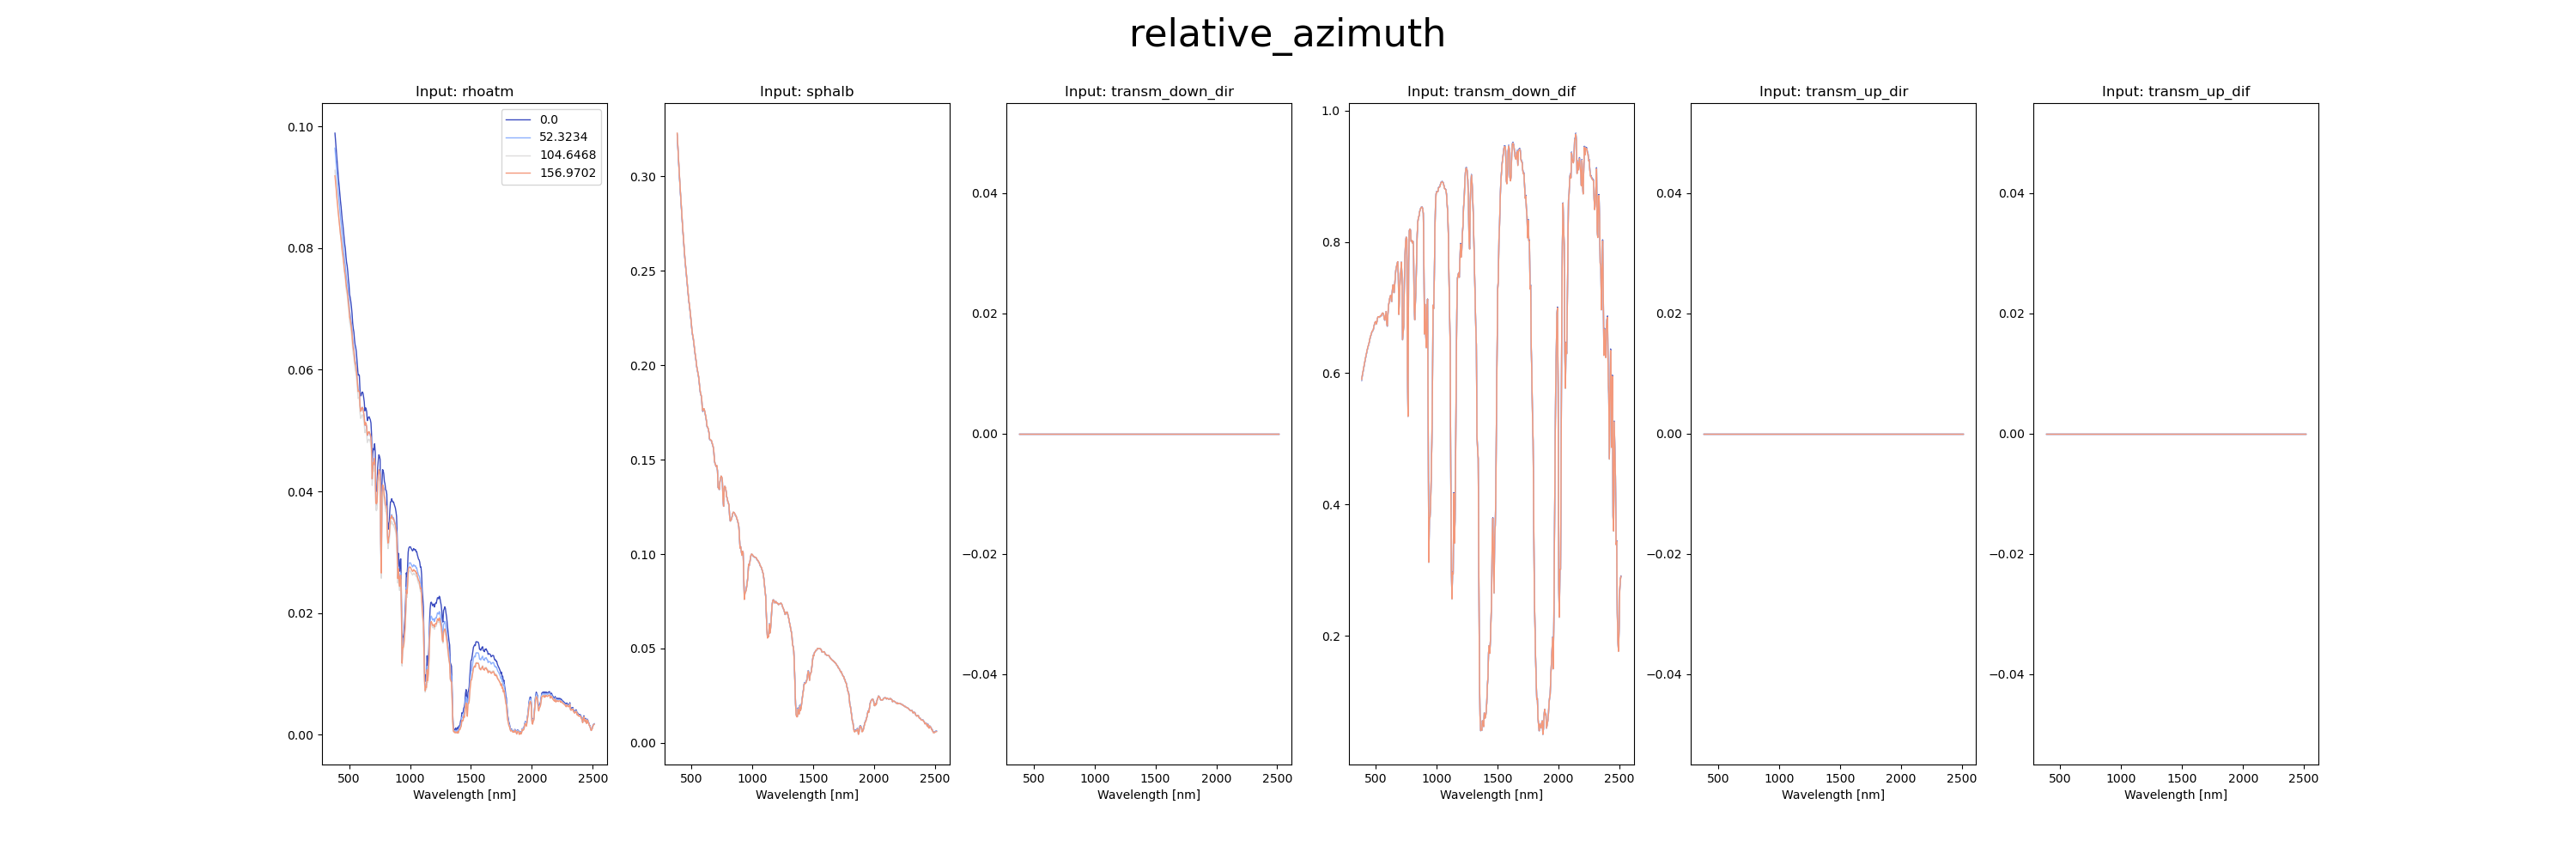

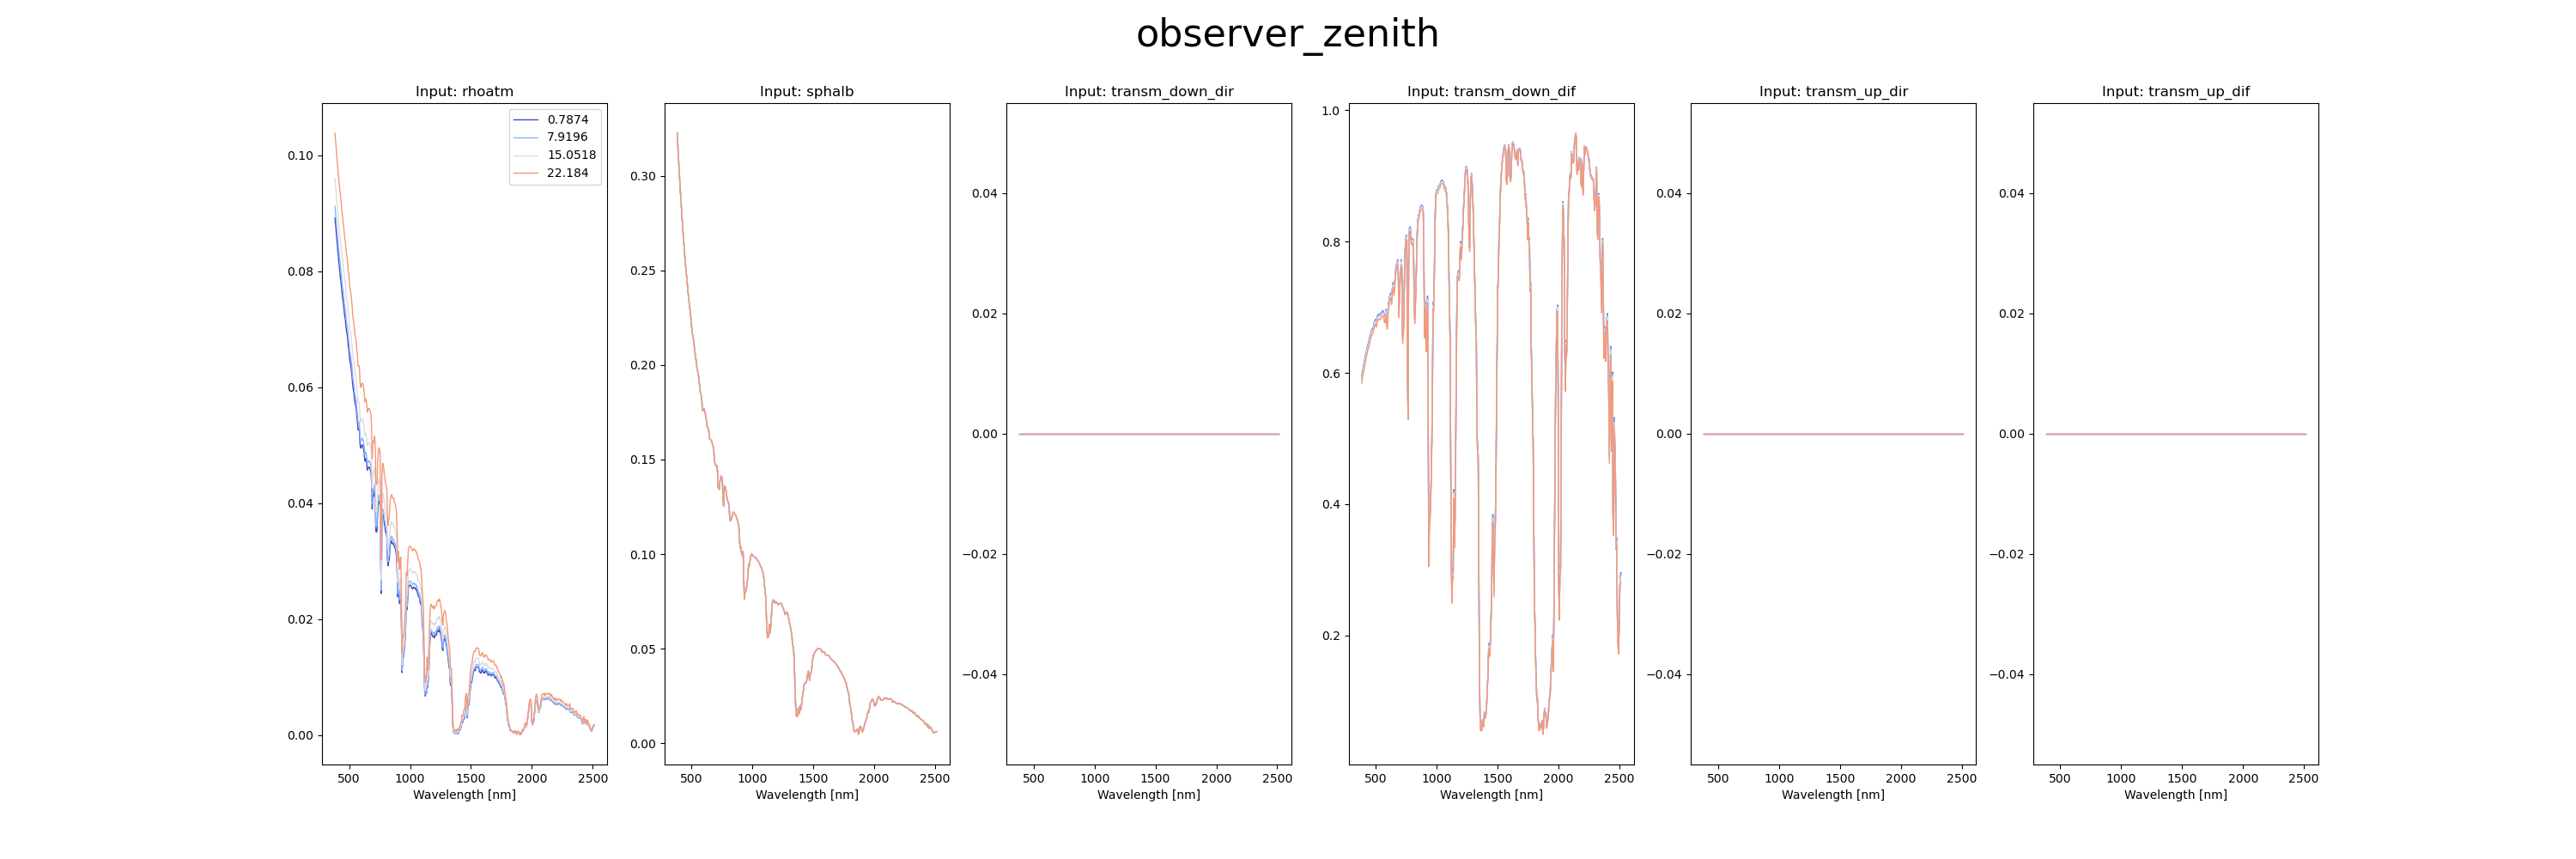

In [7]:
plots.rtms.RTMs(fp_lut)